# SCoRE Package Demonstration
This notebook demonstrates how to import and use the functionality provided by the `SCoRE` package for selective prediction and risk-controlled selection.

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split

from SCoRE import gen_data_2, loss_2
from SCoRE import SCoRE_MDR, eval_MDR
from SCoRE import SCoRE_SDR_fast, eval_SDR

import matplotlib.pyplot as plt

### 0. Get a Pre-trained Model
We first obtain a model for us to perform selective prediction. Note that the training data and model here can be arbitrary.

In [2]:
setting = 1 # data generation
sig = 0.1
dim = 20
clip_const = 2

In [3]:
Xprep, _, _, Yprep = gen_data_2(setting=setting, n=1000, sig=sig, dim=dim)
f = RandomForestRegressor()
f.fit(Xprep, Yprep)

RandomForestRegressor()

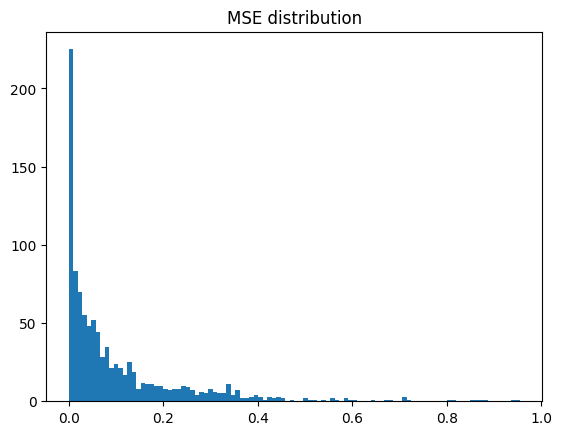

In [4]:
Xval, _, _, Yval= gen_data_2(setting=setting, n=1000, sig=sig, dim=dim)
MSE = loss_2(Yval, f, Xval, clip_const) # clipped and standardized MSE
plt.hist(MSE, bins=100)
plt.title('MSE distribution')
plt.show()

### 1. Generate Synthetic Data
Given the model, we generate synthetic data and split it into training, calibration, and test sets.

In [5]:
n_samples = 2000

# Generate data
X, _, _, Y = gen_data_2(setting=1, n=n_samples, sig=sig, dim=dim)

# Split datasets
Xtrain, Xtemp, Ytrain, Ytemp = train_test_split(X, Y, test_size=0.5, random_state=42)
Xcalib, Xtest, Ycalib, Ytest = train_test_split(Xtemp, Ytemp, test_size=0.5, random_state=42)

print(f"Train size: {len(Xtrain)}, Calib size: {len(Xcalib)}, Test size: {len(Xtest)}")

Train size: 1000, Calib size: 500, Test size: 500


In [6]:
# Evaluate the loss and reward on each dataset (we would not have access to Ltest in practice)
Ltrain, Lcalib, Ltest = loss_2(Ytrain, f, Xtrain, clip_const), loss_2(Ycalib, f, Xcalib, clip_const), loss_2(Ytest, f, Xtest, clip_const)
Rtrain, Rcalib, Rtest = Ytrain ** 2, Ycalib ** 2, Ytest ** 2

### 2. Train a Loss Model
Train a simple model on the training set for loss prediction

In [7]:
model = RandomForestRegressor()
model.fit(Xtrain, Ltrain)

# Get loss predictions
Lcalib_pred = model.predict(Xcalib)
Ltest_pred = model.predict(Xtest)

# Get the (Loss, Score) tuples
Dcalib = (Lcalib, Lcalib_pred)
Dtest = (np.zeros_like(Ltest_pred), Ltest_pred)  # True Ltest should not and need not be accessed by SCoRE

### 3. Apply SCoRE Risk Control
Run `SCoRE_MDR` or `SCoRE_SDR` to select a subset of the test instances while controlling the risk.

#### 3.1 MDR Control

In [8]:
alpha = 0.03
gamma = 0.03

mdr_selected_indices = SCoRE_MDR(Dcalib, Dtest, alpha=alpha, gamma=gamma)
print(f"Selected {len(mdr_selected_indices)} out of {len(Ltest_pred)} test instances.")

Selected 285 out of 500 test instances.


We now evaluate the empirical risk of the selected instances.

In [9]:
risk, reward = eval_MDR(Ltest, Rtest, mdr_selected_indices)
print(f"Empirical Risk on selected (should be <= {alpha} ideally): {risk:.4f}")
print(f"Total Reward of selected: {reward:.2f}")

Empirical Risk on selected (should be <= 0.03 ideally): 0.0296
Total Reward of selected: 2618.26


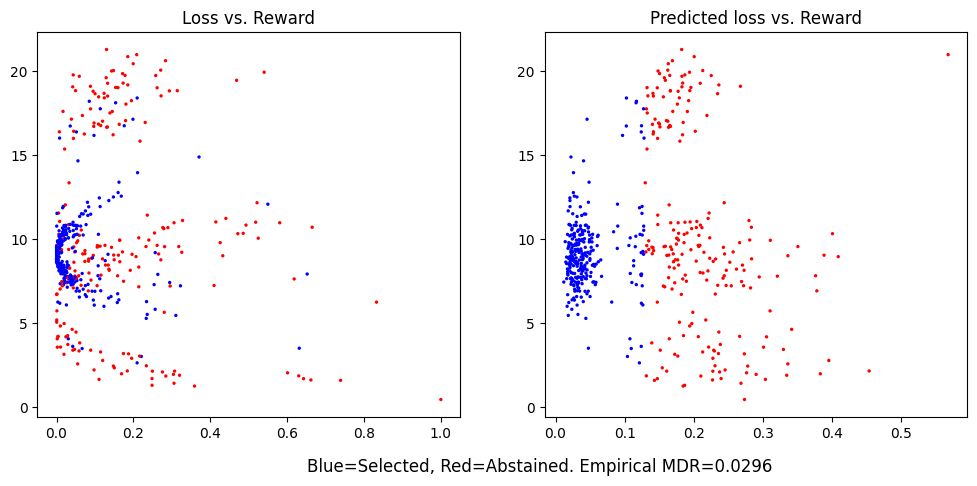

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
ax[0].scatter(Ltest, Rtest, s=2, c=['blue' if i in mdr_selected_indices else 'red' for i in range(len(Ltest))])
ax[1].scatter(Ltest_pred, Rtest, s=2, c=['blue' if i in mdr_selected_indices else 'red' for i in range(len(Ltest))])
ax[0].set_title("Loss vs. Reward")
ax[1].set_title("Predicted loss vs. Reward")
fig.text(0.35, 0, f"Blue=Selected, Red=Abstained. Empirical MDR={risk:.4f}", fontsize=12)
plt.show()

#### 3.2 SDR Control

In [11]:
alpha = 0.04
gamma = 0.04

sdr_selected_indices = SCoRE_SDR_fast(Dcalib, Dtest, alpha=alpha, gamma=gamma, prune='homo')
print(f"Selected {len(sdr_selected_indices)} out of {len(Ltest_pred)} test instances.")

Selected 252 out of 500 test instances.


In [12]:
risk, _, reward = eval_SDR(Ltest, Rtest, sdr_selected_indices)
print(f"Empirical Risk on selected (should be <= {alpha} ideally): {risk:.4f}")
print(f"Total Reward of selected: {reward:.2f}")

Empirical Risk on selected (should be <= 0.04 ideally): 0.0438
Total Reward of selected: 2287.68


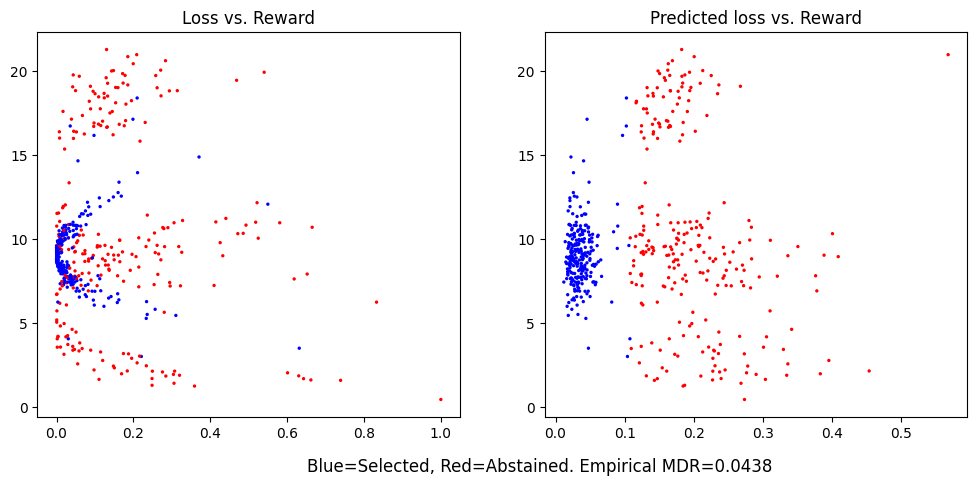

In [13]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
ax[0].scatter(Ltest, Rtest, s=2, c=['blue' if i in sdr_selected_indices else 'red' for i in range(len(Ltest))])
ax[1].scatter(Ltest_pred, Rtest, s=2, c=['blue' if i in sdr_selected_indices else 'red' for i in range(len(Ltest))])
ax[0].set_title("Loss vs. Reward")
ax[1].set_title("Predicted loss vs. Reward")
fig.text(0.35, 0, f"Blue=Selected, Red=Abstained. Empirical MDR={risk:.4f}", fontsize=12)
plt.show()